In [164]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from data import load_training_data
from data import data_stats

In [3]:
train_path = r'C:\kaggle_ev_purchase\data\raw\train.csv'
df_train = load_training_data(train_path)
df_train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0
Will_Buy_EV,668665.0,0.174645,0.379663,0.0,0.0,0.0,0.0,1.0




--- Valores Únicos Categóricos ---
valores únicos da coluna: Gender
['Male', 'Female', 'Other']
valores únicos da coluna: City_Type
['Suburban', 'Rural', 'Urban']
valores únicos da coluna: Current_Car_Type
['Sedan', 'SUV', 'Hatchback', 'Truck']
valores únicos da coluna: Home_Charging_Possible
['Yes', 'No']
valores únicos da coluna: Subsidy_Available
['No', 'Yes']
valores únicos da coluna: Range_Anxiety_Level
['Low', 'Medium', 'High']


--- Valores Únicos Categóricos ---
Não Comprou (0): 82.54%
Comprou (1): 17.46%


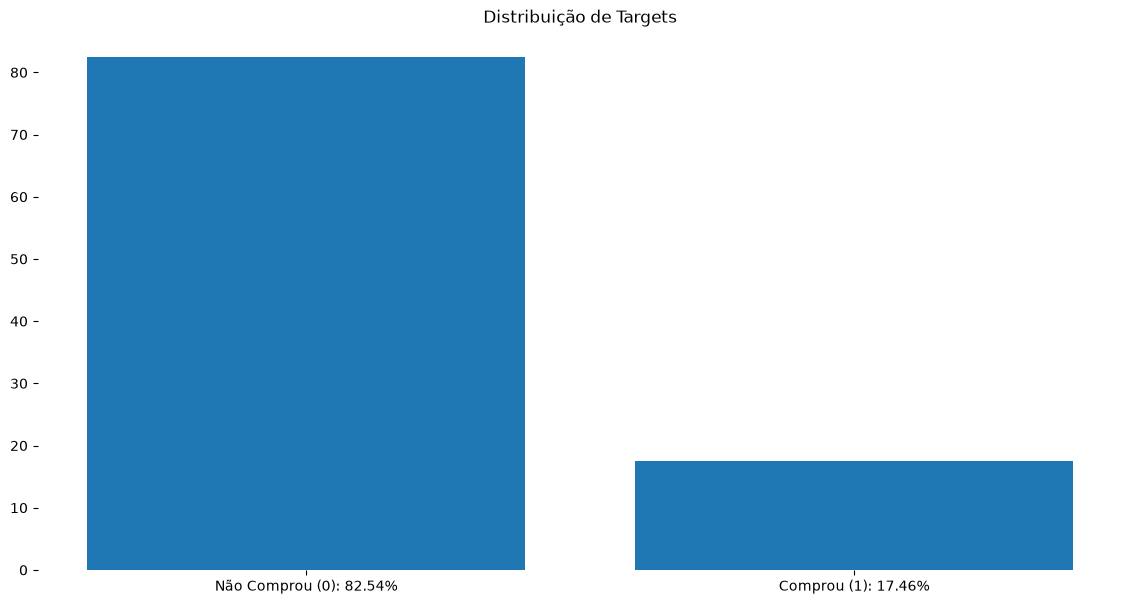

In [4]:
data_stats(df_train)

Análise Exploraatória de Dados

Correlação entre features e Target
--------------------------------------------------
Will_Buy_EV                    1.000000
Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Number_of_Cars_Owned           0.003896
Age                           -0.007450
Charging_Stations_Near_Work   -0.012229
Charging_Stations_Near_Home   -0.016353
Daily_Commute_km              -0.045866
Name: Will_Buy_EV, dtype: float64
--------------------------------------------------


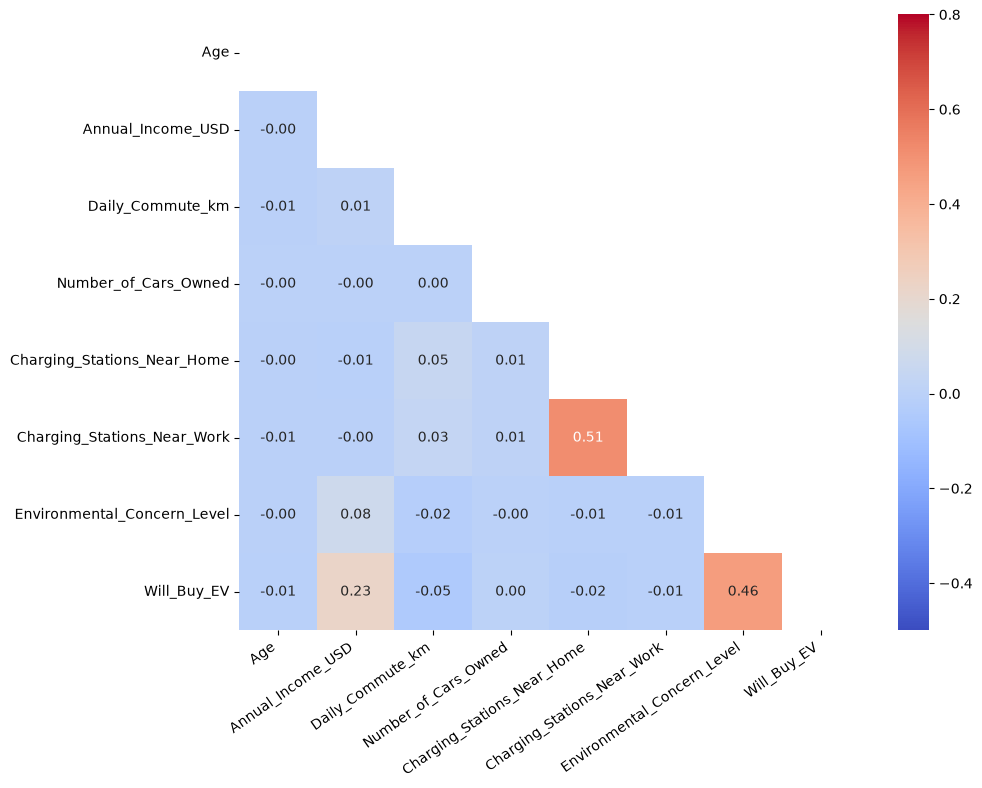

In [190]:
df_filtro = df_train.select_dtypes(include='number').drop(columns='id')
corr = df_filtro.corr()
print('Correlação entre features e Target')
print(50*'-')
print(df_filtro.corr()['Will_Buy_EV'].sort_values(ascending=False))
print(50*'-')


mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin = -0.5, vmax= 0.8,mask=mask)

plt.xticks(
    rotation=35, ha='right', fontsize=10)

plt.show()

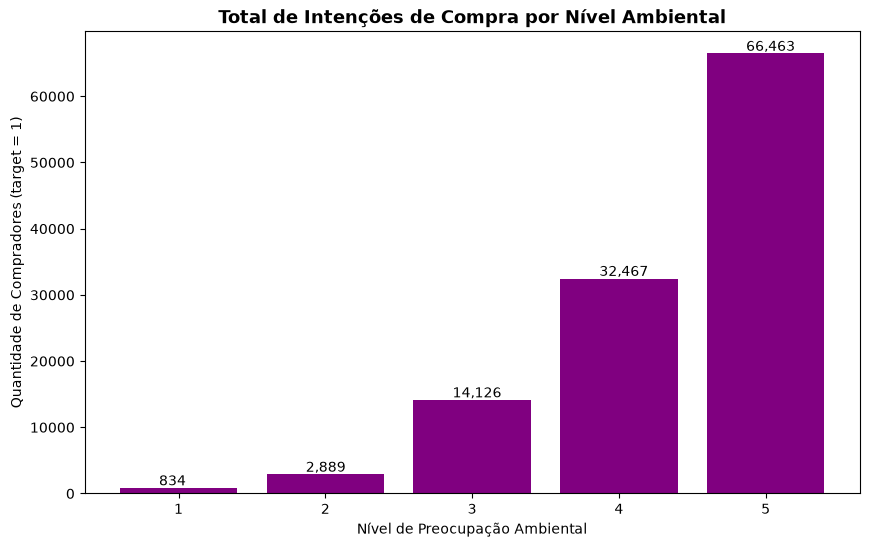

In [143]:
concern = df_train.groupby('Environmental_Concern_Level')['Will_Buy_EV'].sum()
eixo_y = concern.values
eixo_x = concern.index.astype(int)

plt.figure(figsize=(10, 6))
barras = plt.bar(eixo_x, eixo_y, color='purple')

plt.title('Total de Intenções de Compra por Nível Ambiental', fontsize=13, fontweight='bold')
plt.xlabel('Nível de Preocupação Ambiental')
plt.ylabel('Quantidade de Compradores (target = 1)')

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/3, altura + 400, f'{int(altura):,}')

plt.show()

In [200]:
categorical_cols = df_train.select_dtypes(
    include=["object", "string", "category"]).columns

for col in categorical_cols:
    print(f"\n{col}")

    tabela = (
        df_train.groupby(col)["Will_Buy_EV"]
        .agg(quantidade="size", quantidade_que_compra_EV='sum')
    )

    tabela['quantidade_que_compra_EV'] = (tabela['quantidade_que_compra_EV']/tabela['quantidade']) * 100

    display(tabela.round(2))


Gender


,quantidade,quantidade_que_compra_EV
Gender,,
Female,295427,17.76
Male,367954,17.23
Other,5284,17.37



City_Type


,quantidade,quantidade_que_compra_EV
City_Type,,
Rural,123983,19.34
Suburban,255377,18.09
Urban,289305,16.11



Current_Car_Type


...

,quantidade,quantidade_que_compra_EV
Home_Charging_Possible,,
No,205988,12.71
Yes,462677,19.58



Subsidy_Available


,quantidade,quantidade_que_compra_EV
Subsidy_Available,,
No,248756,0.58
Yes,419909,27.47



Range_Anxiety_Level


,quantidade,quantidade_que_compra_EV
Range_Anxiety_Level,,
High,2194,0.14
Low,603972,18.90
Medium,62499,4.17
